-------------------------------
-------------------------------
# Proyecto 2 - Minería de Datos (CC3074)
* Dulce Ambrosio - 231143
* Daniel Chet - 231177
* Javier Linares - 231135
* Cristian Túnchez - 231359

-------------------------------
-------------------------------

-------------------------------
**Semana 3:** Mejora de modelos + seleción

-------------------------------

-------------------------------
Importación de librerías y carga del dataset (Se realizó basandose en la semana 1 y semana 2)

-------------------------------

In [1]:
# Importación de librerías base para manejo de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suprimir advertencias para mantener la salida limpia
import warnings
warnings.filterwarnings('ignore')

# Importación de modelos y utilidades de scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold,
    GridSearchCV, learning_curve
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Configuración de visualización (tamaño de figura y estilo)
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')


In [2]:
# Carga y limpieza del dataset (reproduciendo el pipeline de Semanas 1 y 2)
# - Lee el CSV
# - Convierte la columna "Bare Nuclei" a numérico (si hubiera '?', se vuelve NaN)
# - Elimina registros con valores faltantes
# - Asegura el tipo de "Class" y elimina el identificador si existe

df = pd.read_csv('Datos.csv')

# Limpieza: Bare Nuclei puede tener '?' en algunas versiones del dataset
df['Bare Nuclei'] = pd.to_numeric(df['Bare Nuclei'], errors='coerce')
df.dropna(inplace=True)
df['Class'] = df['Class'].astype(int)

# Eliminar columna identificadora
if 'Sample code number' in df.columns:
    df.drop(columns=['Sample code number'], inplace=True)

# Resumen rápido del dataset resultante
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
print(f'Distribución de clases:\n{df["Class"].value_counts()}')

Dataset cargado: 683 registros, 10 columnas
Distribución de clases:
Class
2    444
4    239
Name: count, dtype: int64


In [3]:
# Preparación de variables:
# - X: features (todas las columnas excepto Class)
# - y: etiqueta binaria (2 -> 0 Benigno, 4 -> 1 Maligno)
# - Escalado con StandardScaler (necesario para modelos sensibles a escala)
# - Split estratificado train/test para mantener proporciones de clase

X = df.drop(columns=['Class'])
y = df['Class'].map({2: 0, 4: 1})  # Binarizar: 0=Benigno, 1=Maligno

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Prueba:        {X_test.shape[0]} muestras')

Entrenamiento: 546 muestras
Prueba:        137 muestras


-------------------------------
**Cross - Validation (Validación Cruzada):** Se utiliza stratified K-fold con k=10 para estimar el rendimiendo de los modelos base de forma más confiable, evitando el sesgo de ua sola partición train/test

-------------------------------

In [4]:
# Configuración de validación cruzada (Stratified K-Fold):
# - Mantiene proporción de clases en cada fold
# - Shuffle + random_state para reproducibilidad
#
# Evaluación de modelos "base" (sin tuning) usando métricas estándar.

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Modelos base (sin optimizar, para comparación)
modelos_base = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión':   DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(random_state=42)
}

metricas_cv = {}

for nombre, modelo in modelos_base.items():
    # Cada métrica se estima en CV de forma independiente
    acc    = cross_val_score(modelo, X_scaled, y, cv=cv, scoring='accuracy')
    prec   = cross_val_score(modelo, X_scaled, y, cv=cv, scoring='precision')
    rec    = cross_val_score(modelo, X_scaled, y, cv=cv, scoring='recall')
    f1     = cross_val_score(modelo, X_scaled, y, cv=cv, scoring='f1')
    metricas_cv[nombre] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1
    }

    # Reporte: media ± desviación estándar
    print(f'\n{nombre}:')
    print(f'  Accuracy  : {acc.mean():.4f} ± {acc.std():.4f}')
    print(f'  Precision : {prec.mean():.4f} ± {prec.std():.4f}')
    print(f'  Recall    : {rec.mean():.4f} ± {rec.std():.4f}')
    print(f'  F1-Score  : {f1.mean():.4f} ± {f1.std():.4f}')


Regresión Logística:
  Accuracy  : 0.9693 ± 0.0190
  Precision : 0.9594 ± 0.0307
  Recall    : 0.9542 ± 0.0542
  F1-Score  : 0.9555 ± 0.0286

Árbol de Decisión:
  Accuracy  : 0.9517 ± 0.0252
  Precision : 0.9377 ± 0.0305
  Recall    : 0.9246 ± 0.0717
  F1-Score  : 0.9293 ± 0.0403

Random Forest:
  Accuracy  : 0.9736 ± 0.0127
  Precision : 0.9556 ± 0.0275
  Recall    : 0.9708 ± 0.0267
  F1-Score  : 0.9627 ± 0.0178


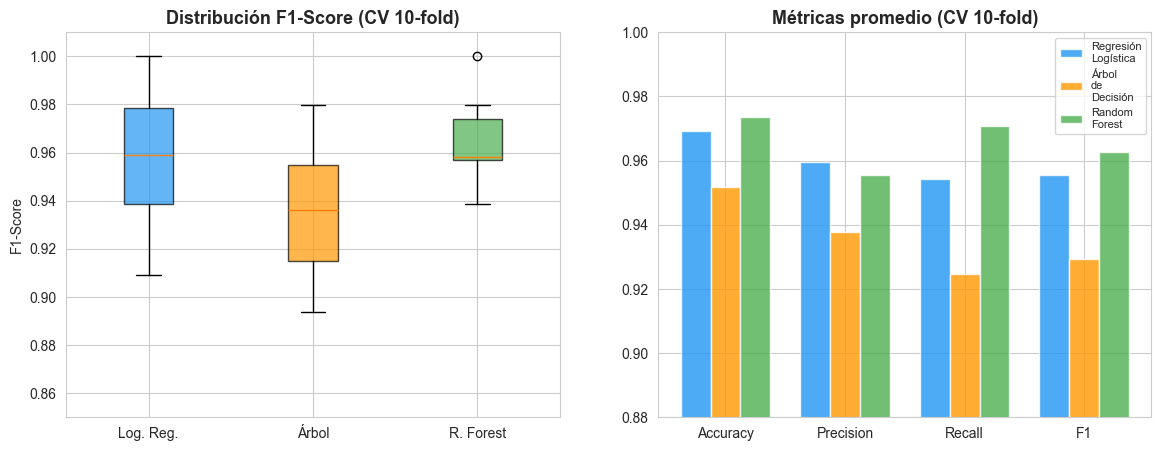

In [5]:
# Visualización: Comparación de métricas de CV
# - Izquierda: boxplot de la distribución del F1 por fold
# - Derecha: barras con las métricas promedio por modelo

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

nombres = list(metricas_cv.keys())
colores = ['#2196F3', '#FF9800', '#4CAF50']

# Boxplot de F1 (variabilidad por fold)
f1_data = [metricas_cv[n]['F1'] for n in nombres]
bp = axes[0].boxplot(f1_data, labels=['Log. Reg.', 'Árbol', 'R. Forest'],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Distribución F1-Score (CV 10-fold)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('F1-Score')
axes[0].set_ylim(0.85, 1.01)

# Barras comparativas (medias)
metricas_labels = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(metricas_labels))
width = 0.25
for i, (nombre, color) in enumerate(zip(nombres, colores)):
    # Media de cada métrica en CV para el modelo
    medias = [metricas_cv[nombre][m].mean() for m in metricas_labels]
    axes[1].bar(x + i*width, medias, width, label=nombre.replace(' ', '\n'),
                color=color, alpha=0.8)
axes[1].set_title('Métricas promedio (CV 10-fold)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(metricas_labels)
axes[1].set_ylim(0.88, 1.0)
axes[1].legend(fontsize=8)




-------------------------------
**Análisis de Overfitting vs Underfitting (Curvas de Aprendizaje):** estas curvas de aprendizaje muestran cómo evoluciona el rendimiento de entrenamiento vs validación a medida que aumenta el tamaño del conjunto de entrenamiento, lo que permite diagnosticar sesgo (Underfitting) o varianza (Overfittign)

-------------------------------

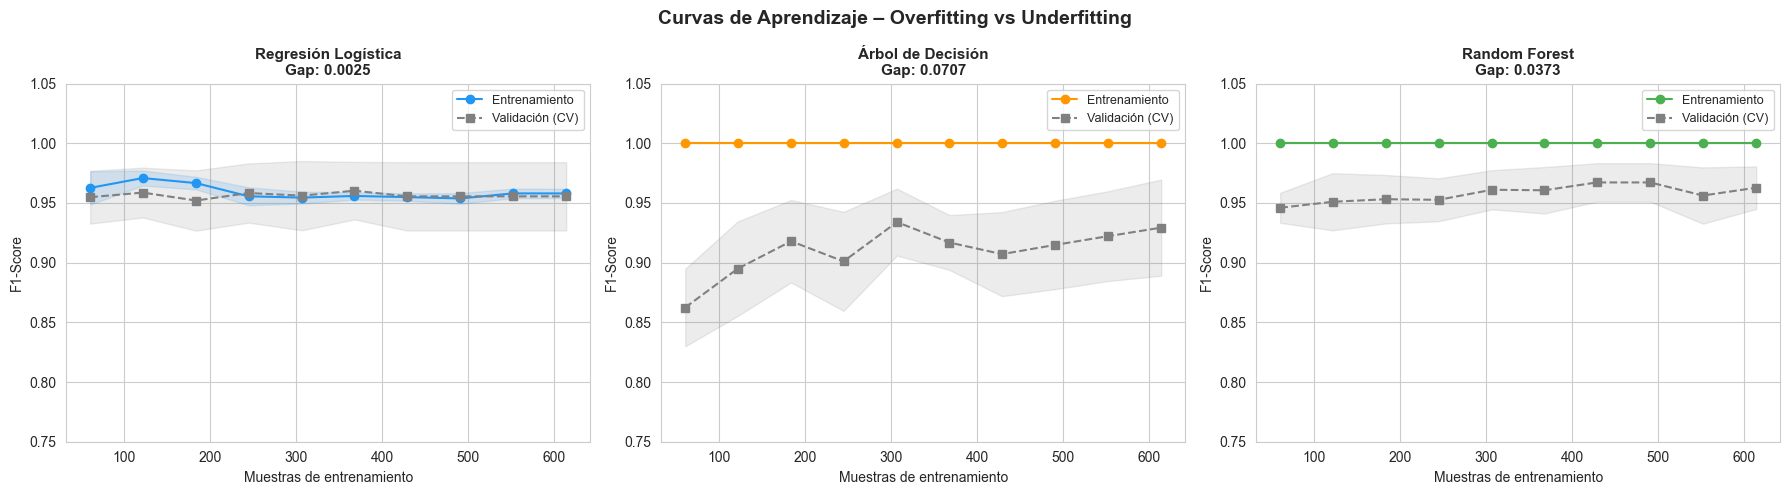

In [6]:
# Curvas de aprendizaje (Learning Curves)
# Se usa para comparar desempeño de entrenamiento vs validación según crece el set de entrenamiento.
# Esto ayuda a diagnosticar underfitting (sesgo) vs overfitting (varianza).

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

modelos_list = [
    ('Regresión Logística', LogisticRegression(max_iter=1000, random_state=42), '#2196F3'),
    ('Árbol de Decisión',   DecisionTreeClassifier(random_state=42), '#FF9800'),
    ('Random Forest',       RandomForestClassifier(random_state=42), '#4CAF50'),
]

for ax, (nombre, modelo, color) in zip(axes, modelos_list):
    # learning_curve devuelve scores para distintos tamaños de entrenamiento
    train_sizes, train_scores, val_scores = learning_curve(
        modelo, X_scaled, y,
        cv=cv, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10),
        n_jobs=-1
    )
    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    # Línea de entrenamiento
    ax.plot(train_sizes, train_mean, 'o-', color=color,   label='Entrenamiento')
    ax.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15, color=color)

    # Línea de validación (CV)
    ax.plot(train_sizes, val_mean, 's--', color='gray',   label='Validación (CV)')
    ax.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15, color='gray')

    # Gap al final: diferencia entre train y validación
    gap = (train_mean[-1] - val_mean[-1])
    ax.set_title(f'{nombre}\nGap: {gap:.4f}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('F1-Score')
    ax.set_ylim(0.75, 1.05)
    ax.legend(fontsize=9)

plt.suptitle('Curvas de Aprendizaje – Overfitting vs Underfitting', fontsize=14, fontweight='bold')
plt.tight_layout()


-------------------------------
**Afinación de Hiperparámetros (Hyperparameter Tuning):** Se utiliza GridSearch CV con validación cruzada estratificada (k=10) para encontrar los mejores hiperparámetros de cada modelo. La métruca de optimización es Recall, por el contexto médico, por que los falsos negativos tienen el mayor costo 

-------------------------------

In [7]:
# ─────────────────────────────────────────
# Afinación de hiperparámetros (GridSearchCV) — Regresión Logística
# - Se exploran combinaciones de C y penalty
# - Métrica objetivo: recall (sensibilidad), priorizando minimizar falsos negativos
# ─────────────────────────────────────────

# ─────────────────────────────────────────
# Regresión Logística
# ─────────────────────────────────────────
param_grid_lr = {
    'C':        [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty':  ['l1', 'l2'],
    'solver':   ['liblinear']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr, cv=cv, scoring='recall', n_jobs=-1
)
grid_lr.fit(X_train, y_train)

print('Regresión Logística – Mejores hiperparámetros:')
print(f'  {grid_lr.best_params_}')
print(f'  Recall CV (train): {grid_lr.best_score_:.4f}')

Regresión Logística – Mejores hiperparámetros:
  {'C': 0.001, 'penalty': 'l2', 'solver': 'liblinear'}
  Recall CV (train): 0.9634


In [8]:
# ─────────────────────────────────────────
# Afinación de hiperparámetros (GridSearchCV) — Árbol de Decisión
# - Controla complejidad con max_depth, min_samples_split, min_samples_leaf
# - Se comparan criterios (gini vs entropy)
# - Métrica objetivo: recall
# ─────────────────────────────────────────

# ─────────────────────────────────────────
# Árbol de Decisión
# ─────────────────────────────────────────
param_grid_dt = {
    'max_depth':        [3, 5, 7, 10, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion':        ['gini', 'entropy']
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt, cv=cv, scoring='recall', n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print('Árbol de Decisión – Mejores hiperparámetros:')
print(f'  {grid_dt.best_params_}')
print(f'  Recall CV (train): {grid_dt.best_score_:.4f}')

Árbol de Decisión – Mejores hiperparámetros:
  {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Recall CV (train): 0.9526


In [9]:
# ─────────────────────────────────────────
# Afinación de hiperparámetros (GridSearchCV) — Random Forest
# - Ajusta número de árboles, profundidad y parámetros de partición
# - max_features controla aleatoriedad por split
# - Métrica objetivo: recall
# ─────────────────────────────────────────

# ─────────────────────────────────────────
# Random Forest
# ─────────────────────────────────────────
param_grid_rf = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [5, 10, None],
    'min_samples_split':[2, 5],
    'min_samples_leaf': [1, 2],
    'max_features':     ['sqrt', 'log2']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf, cv=cv, scoring='recall', n_jobs=-1
)
grid_rf.fit(X_train, y_train)

print('Random Forest – Mejores hiperparámetros:')
print(f'  {grid_rf.best_params_}')
print(f'  Recall CV (train): {grid_rf.best_score_:.4f}')

Random Forest – Mejores hiperparámetros:
  {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 50}
  Recall CV (train): 0.9789


-------------------------------
**Evaluación de Modelos Optimizados en Test Set** 

-------------------------------

In [10]:
# Evaluación en test set para los mejores estimadores encontrados en GridSearchCV
# Se calcula Accuracy, Precision, Recall, F1 y AUC-ROC (si el modelo soporta predict_proba).

def evaluar_modelo(nombre, modelo, X_train, y_train, X_test, y_test):
    # Entrenamiento final del estimador seleccionado
    modelo.fit(X_train, y_train)

    # Predicciones en el conjunto de prueba
    y_pred = modelo.predict(X_test)

    # Probabilidades (para AUC/ROC); algunos modelos podrían no implementarlo
    y_prob = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, 'predict_proba') else None

    # Métricas principales
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)

    # AUC-ROC requiere probabilidades
    auc  = roc_auc_score(y_test, y_prob) if y_prob is not None else None

    # Matriz de confusión para ver FN/FP explícitamente
    cm   = confusion_matrix(y_test, y_pred)

    # Impresión del reporte del modelo
    print(f'\n{'='*50}')
    print(f'{nombre} (optimizado)')
    print(f'{'='*50}')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')
    print(f'  F1-Score : {f1:.4f}')
    if auc: print(f'  AUC-ROC  : {auc:.4f}')
    print(f'  Matriz de confusión: {cm.tolist()}')

    # Retornar todo lo necesario para gráficas/comparación posterior
    return {'nombre': nombre, 'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1, 'auc': auc, 'cm': cm, 'y_prob': y_prob}

# Evaluación de cada mejor estimador (uno por familia de modelos)
res_lr = evaluar_modelo('Regresión Logística', grid_lr.best_estimator_, X_train, y_train, X_test, y_test)
res_dt = evaluar_modelo('Árbol de Decisión',   grid_dt.best_estimator_, X_train, y_train, X_test, y_test)
res_rf = evaluar_modelo('Random Forest',       grid_rf.best_estimator_, X_train, y_train, X_test, y_test)

# Lista unificada para iterar en visualizaciones
resultados = [res_lr, res_dt, res_rf]


Regresión Logística (optimizado)
  Accuracy : 0.9635
  Precision: 0.9216
  Recall   : 0.9792
  F1-Score : 0.9495
  AUC-ROC  : 0.9934
  Matriz de confusión: [[85, 4], [1, 47]]

Árbol de Decisión (optimizado)
  Accuracy : 0.9343
  Precision: 0.9149
  Recall   : 0.8958
  F1-Score : 0.9053
  AUC-ROC  : 0.9787
  Matriz de confusión: [[85, 4], [5, 43]]

Random Forest (optimizado)
  Accuracy : 0.9635
  Precision: 0.9216
  Recall   : 0.9792
  F1-Score : 0.9495
  AUC-ROC  : 0.9874
  Matriz de confusión: [[85, 4], [1, 47]]


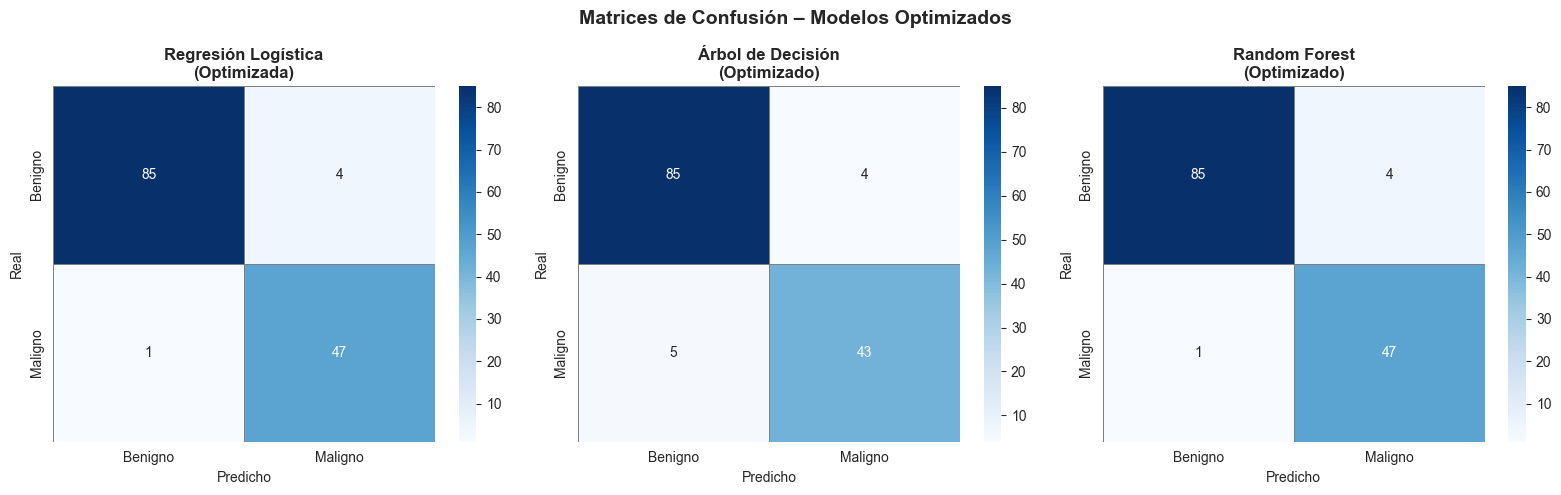

In [11]:
# Matrices de confusión – modelos optimizados
# Visualiza TP/TN/FP/FN para cada modelo en el conjunto de prueba.

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titulos = ['Regresión Logística\n(Optimizada)', 'Árbol de Decisión\n(Optimizado)', 'Random Forest\n(Optimizado)']

for ax, res, titulo in zip(axes, resultados, titulos):
    # Heatmap para lectura más clara
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benigno', 'Maligno'],
                yticklabels=['Benigno', 'Maligno'], ax=ax,
                linewidths=0.5, linecolor='gray')
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.suptitle('Matrices de Confusión – Modelos Optimizados', fontsize=14, fontweight='bold')
plt.tight_layout()

-------------------------------
**Curvas ROC** 

-------------------------------

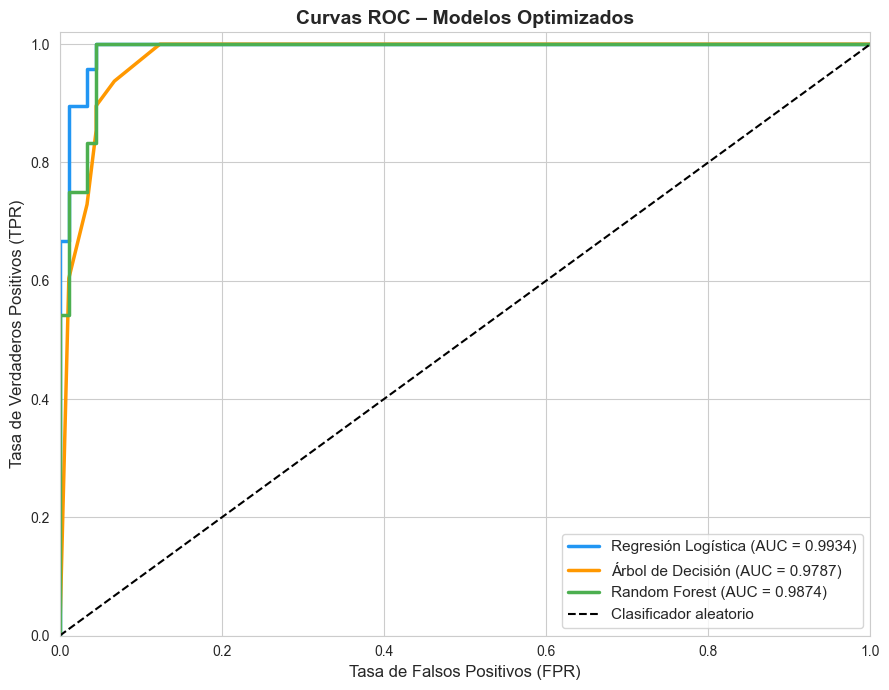

In [12]:
# Curvas ROC (Receiver Operating Characteristic)
# - Se grafican TPR vs FPR para cada modelo optimizado
# - El AUC resume el área bajo la curva (mayor es mejor)

fig, ax = plt.subplots(figsize=(9, 7))

colores_roc = ['#2196F3', '#FF9800', '#4CAF50']
for res, color in zip(resultados, colores_roc):
    # Solo se puede trazar ROC si existen probabilidades
    if res['y_prob'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        ax.plot(fpr, tpr, color=color, lw=2.5,
                label=f"{res['nombre']} (AUC = {res['auc']:.4f})")

# Línea base: clasificador aleatorio
ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC – Modelos Optimizados', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()

-------------------------------
**Comparación Formal: Base vs Optimizado** 

-------------------------------

In [13]:
# Comparación formal: Base (Semana 2) vs Optimizado (Semana 3)
# Se reportan métricas por modelo y el delta (Optimizado - Base).

# Resultados base (Semana 2) para comparación directa
base = {
    'Regresión Logística': {'acc': 0.956, 'prec': 0.981, 'rec': 0.914, 'f1': 0.946},
    'Árbol de Decisión':   {'acc': 0.934, 'prec': 0.962, 'rec': 0.879, 'f1': 0.919},
    'Random Forest':       {'acc': 0.949, 'prec': 0.981, 'rec': 0.897, 'f1': 0.937},
}

print('\n')
print(f'{"Modelo":<25} {"Métrica":<12} {"Base":>8} {"Optimizado":>12} {"Δ":>8}')
print('-'*70)

for res in resultados:
    nombre = res['nombre']
    # Iteración por métricas para no repetir código
    for met_key, met_label in [("acc","Accuracy"),("prec","Precision"),("rec","Recall"),("f1","F1-Score")]:
        b = base[nombre][met_key]
        o = res[met_key]
        delta = o - b
        signo = '+' if delta >= 0 else ''
        print(f'{nombre:<25} {met_label:<12} {b:>8.4f} {o:>12.4f} {signo+f"{delta:.4f}":>8}')
    print()



Modelo                    Métrica          Base   Optimizado        Δ
----------------------------------------------------------------------
Regresión Logística       Accuracy       0.9560       0.9635  +0.0075
Regresión Logística       Precision      0.9810       0.9216  -0.0594
Regresión Logística       Recall         0.9140       0.9792  +0.0652
Regresión Logística       F1-Score       0.9460       0.9495  +0.0035

Árbol de Decisión         Accuracy       0.9340       0.9343  +0.0003
Árbol de Decisión         Precision      0.9620       0.9149  -0.0471
Árbol de Decisión         Recall         0.8790       0.8958  +0.0168
Árbol de Decisión         F1-Score       0.9190       0.9053  -0.0137

Random Forest             Accuracy       0.9490       0.9635  +0.0145
Random Forest             Precision      0.9810       0.9216  -0.0594
Random Forest             Recall         0.8970       0.9792  +0.0822
Random Forest             F1-Score       0.9370       0.9495  +0.0125



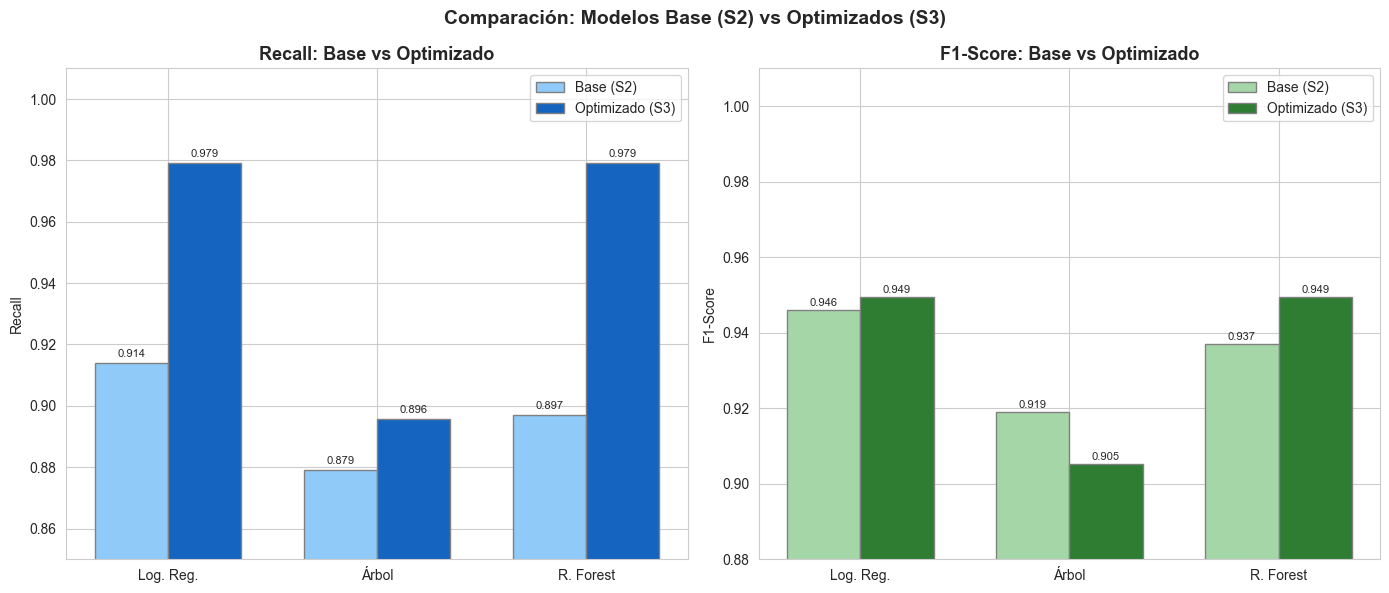

In [14]:
# Visualización comparativa: Recall y F1 (Base vs Optimizado)
# Permite ver de forma rápida si el tuning mejoró la sensibilidad (recall) y el balance (F1).

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

nombres_cortos = ['Log. Reg.', 'Árbol', 'R. Forest']
x = np.arange(3)
w = 0.35

# Recall
rec_base = [base[r['nombre']]['rec'] for r in resultados]
rec_opt  = [r['rec'] for r in resultados]
axes[0].bar(x - w/2, rec_base, w, label='Base (S2)', color='#90CAF9', edgecolor='gray')
axes[0].bar(x + w/2, rec_opt,  w, label='Optimizado (S3)', color='#1565C0', edgecolor='gray')
axes[0].set_xticks(x); axes[0].set_xticklabels(nombres_cortos)
axes[0].set_ylim(0.85, 1.01)
axes[0].set_title('Recall: Base vs Optimizado', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Recall'); axes[0].legend()
# Etiquetas numéricas sobre barras
for i, (b, o) in enumerate(zip(rec_base, rec_opt)):
    axes[0].text(i-w/2, b+0.002, f'{b:.3f}', ha='center', fontsize=8)
    axes[0].text(i+w/2, o+0.002, f'{o:.3f}', ha='center', fontsize=8)

# F1
f1_base = [base[r['nombre']]['f1'] for r in resultados]
f1_opt  = [r['f1'] for r in resultados]
axes[1].bar(x - w/2, f1_base, w, label='Base (S2)', color='#A5D6A7', edgecolor='gray')
axes[1].bar(x + w/2, f1_opt,  w, label='Optimizado (S3)', color='#2E7D32', edgecolor='gray')
axes[1].set_xticks(x); axes[1].set_xticklabels(nombres_cortos)
axes[1].set_ylim(0.88, 1.01)
axes[1].set_title('F1-Score: Base vs Optimizado', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score'); axes[1].legend()
# Etiquetas numéricas sobre barras
for i, (b, o) in enumerate(zip(f1_base, f1_opt)):
    axes[1].text(i-w/2, b+0.001, f'{b:.3f}', ha='center', fontsize=8)
    axes[1].text(i+w/2, o+0.001, f'{o:.3f}', ha='center', fontsize=8)

plt.suptitle('Comparación: Modelos Base (S2) vs Optimizados (S3)', fontsize=14, fontweight='bold')
plt.tight_layout()


-------------------------------
**Análisis de Sesgo - Varianza (Bias - Variance Tradeoff):** Se analiza el gap entre el rendimiento en entrenamiento y validación cruzada para diagnosticar si cada modelo sufre de sesgo alto (underfitting) o varianza alta (overfitting) 

-------------------------------

In [15]:
# Análisis Sesgo-Varianza (Bias-Variance) en modelos optimizados
# Idea: comparar F1 promedio en entrenamiento (CV sobre train) vs F1 en test.
# - Gap grande: posible overfitting (alta varianza)
# - F1 bajo en entrenamiento: posible underfitting (alto sesgo)

print('Análisis Sesgo-Varianza – Modelos Optimizados')
print('='*60)

for res, grid in zip(resultados, [grid_lr, grid_dt, grid_rf]):
    # Tomar el mejor estimador y ajustar sobre train
    modelo_opt = grid.best_estimator_
    modelo_opt.fit(X_train, y_train)

    # Estimar F1 en entrenamiento vía CV (para comparar contra test)
    train_f1 = cross_val_score(modelo_opt, X_train, y_train, cv=cv, scoring='f1').mean()
    test_f1  = res['f1']
    gap      = train_f1 - test_f1

    # Reglas simples (heurísticas) para diagnóstico
    if gap > 0.05:
        diagnostico = 'Alta varianza (posible overfitting)'
    elif train_f1 < 0.95:
        diagnostico = 'Alto sesgo (posible underfitting)'
    else:
        diagnostico = 'Balance adecuado sesgo-varianza'

    print(f'\n{res["nombre"]}:')
    print(f'  F1 entrenamiento (CV): {train_f1:.4f}')
    print(f'  F1 test:               {test_f1:.4f}')
    print(f'  Gap:                   {gap:.4f}')
    print(f'  Diagnóstico:           {diagnostico}')

Análisis Sesgo-Varianza – Modelos Optimizados

Regresión Logística:
  F1 entrenamiento (CV): 0.9581
  F1 test:               0.9495
  Gap:                   0.0086
  Diagnóstico:           Balance adecuado sesgo-varianza

Árbol de Decisión:
  F1 entrenamiento (CV): 0.9377
  F1 test:               0.9053
  Gap:                   0.0324
  Diagnóstico:           Alto sesgo (posible underfitting)

Random Forest:
  F1 entrenamiento (CV): 0.9689
  F1 test:               0.9495
  Gap:                   0.0194
  Diagnóstico:           Balance adecuado sesgo-varianza


-------------------------------
**Tabla Resumen Final y Selección del Modelo** 

-------------------------------

In [16]:
# Tabla resumen final (test set) y criterio de selección
# En este contexto se prioriza Recall (sensibilidad) para reducir falsos negativos.

df_resumen = pd.DataFrame([
    {
        'Modelo': r['nombre'],
        'Accuracy': f"{r['acc']:.4f}",
        'Precision': f"{r['prec']:.4f}",
        'Recall': f"{r['rec']:.4f}",
        'F1-Score': f"{r['f1']:.4f}",
        'AUC-ROC': f"{r['auc']:.4f}" if r['auc'] else 'N/A'
    } for r in resultados
])

print('\nTabla Resumen – Modelos Optimizados (Semana 3)')
print('='*70)
print(df_resumen.to_string(index=False))

# Identificar el mejor modelo por Recall (métrica prioritaria en contexto médico)
mejor_recall_idx = np.argmax([r['rec'] for r in resultados])
mejor_f1_idx     = np.argmax([r['f1'] for r in resultados])

print(f'\nModelo con mayor Recall:   {resultados[mejor_recall_idx]["nombre"]} → {resultados[mejor_recall_idx]["rec"]:.4f}')
print(f'Modelo con mayor F1-Score: {resultados[mejor_f1_idx]["nombre"]}   → {resultados[mejor_f1_idx]["f1"]:.4f}')
print('\nConclusión: Dado el contexto médico (minimizar falsos negativos),')
print(f'el modelo seleccionado es: {resultados[mejor_recall_idx]["nombre"]}')


Tabla Resumen – Modelos Optimizados (Semana 3)
             Modelo Accuracy Precision Recall F1-Score AUC-ROC
Regresión Logística   0.9635    0.9216 0.9792   0.9495  0.9934
  Árbol de Decisión   0.9343    0.9149 0.8958   0.9053  0.9787
      Random Forest   0.9635    0.9216 0.9792   0.9495  0.9874

Modelo con mayor Recall:   Regresión Logística → 0.9792
Modelo con mayor F1-Score: Regresión Logística   → 0.9495

Conclusión: Dado el contexto médico (minimizar falsos negativos),
el modelo seleccionado es: Regresión Logística


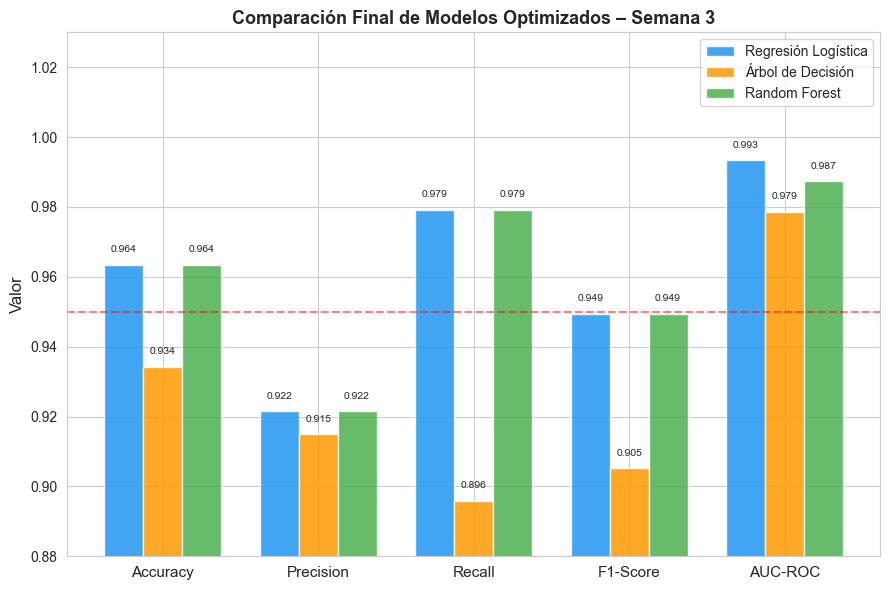

In [17]:
# Visualización final (barras): comparación de métricas por modelo optimizado
# Nota: es un gráfico de barras agrupadas (no radar). Se muestran 5 métricas.

fig, ax = plt.subplots(figsize=(9, 6))

metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
colores_modelos = ['#2196F3', '#FF9800', '#4CAF50']

x = np.arange(len(metricas_nombres))
w = 0.25
for i, (res, color) in enumerate(zip(resultados, colores_modelos)):
    # Si no hay AUC, se usa 0 únicamente para visualizar (no afecta el cálculo previo)
    vals = [res['acc'], res['prec'], res['rec'], res['f1'],
            res['auc'] if res['auc'] else 0]
    bars = ax.bar(x + (i-1)*w, vals, w, label=res['nombre'], color=color, alpha=0.85)

    # Etiquetas numéricas arriba de cada barra
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{v:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metricas_nombres, fontsize=11)
ax.set_ylim(0.88, 1.03)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparación Final de Modelos Optimizados – Semana 3', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Línea de referencia (umbral) para lectura rápida
ax.axhline(0.95, color='red', linestyle='--', alpha=0.5, label='Umbral 95%')
plt.tight_layout()